我用自己設計的『假資料』，來測試變數選擇方法（forward / backward / LASSO）到底選得好不好。
模擬資料：你自己設定：
真實 Y = β₀ + β₁X + β₂X² + β₃X³ + noise
所以你知道「真正重要的變數只有 X, X², X³」
接著做三件事：
把 X, X², …, X¹⁰ 全部丟進去（假裝我不知道真實模型只有到三次方）
用
forward stepwise
backward stepwise
LASSO
來做「變數選擇」
看：
這些方法能不能找回真正的 X, X², X³？
然後換一個真實模型 Y = β₀ + β₇X⁷，再比一次。


8. In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

(a) Create a random number generator and use its normal() method </br>
to generate a predictor X of length n = 100, as well as a noise</br>
vector ϵ of length n = 100.</br>

In [4]:
n = 100
X = np.random.normal(0,1,n)
eps = np.random.normal(0,1,n) 

(b)  
Generate a response vector $Y$ of length $n = 100$ according to the model$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon,$$where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.

In [5]:
# 自行選常數，
# β₀ = 3
# β₁ = 2
# β₂ = −1
# β₃ = 0.5
# Y 就是 cubic polynomial。
# ============ (b) 產生 Y：cubic 真實模型 ============
beta0, beta1, beta2, beta3 = 3.0, 2.0, -1.0, 0.5
Y1 = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + eps

In [8]:
# 普通最小平方法：給定 y 和一些解釋變數 Xdf，回傳 OLS 模型
def fit_ols(y, Xdf):
    X_with_const = sm.add_constant(Xdf)   # 加截距項
    model = sm.OLS(y, X_with_const).fit()
    return model

# 用 full model 估計 σ²（誤差變異），Cp 公式會用到
def compute_sigma2_hat(y, Xdf_full):
    full_model = fit_ols(y, Xdf_full)
    n = len(y)
    k_full = int(full_model.df_model + 1)   # df_model 不含截距，所以 +1
    sigma2_hat = full_model.ssr / (n - k_full)
    return sigma2_hat, full_model

# Mallows’ Cp 指標：Cp = RSS / σ² - (n - 2k)
def cp_stat(model, sigma2_hat):
    n = int(model.nobs)
    k = int(model.df_model + 1)  # 含截距
    rss = model.ssr
    Cp = rss / sigma2_hat - (n - 2*k)
    return Cp


(c)  
Use forward stepwise selection in order to select a model containing the predictors $X, X^2, \dots, X^{10}$. What is the model obtained according to $C_p$? $$C_p = \frac{RSS_d}{\hat{\sigma}^2} - n + 2d$$ Report the coefficients of the model obtained.

In [7]:
# 建立 X, X^2, ..., X^10 的資料表
data = pd.DataFrame({"X": X})
for p in range(2, 11):
    data[f"X{p}"] = X**p
print(data.head(5))

          X        X2        X3        X4        X5        X6            X7  \
0  1.151339  1.325581  1.526193  1.757166  2.023093  2.329266  2.681775e+00   
1  0.370227  0.137068  0.050746  0.018788  0.006956  0.002575  9.534013e-04   
2 -1.244016  1.547576 -1.925210  2.394992 -2.979409  3.706434 -4.610863e+00   
3 -0.724845  0.525401 -0.380834  0.276046 -0.200090  0.145035 -1.051277e-01   
4 -0.115794  0.013408 -0.001553  0.000180 -0.000021  0.000002 -2.791220e-07   

             X8            X9           X10  
0  3.087632e+00  3.554910e+00  4.092907e+00  
1  3.529748e-04  1.306808e-04  4.838153e-05  
2  5.735989e+00 -7.135663e+00  8.876880e+00  
3  7.620128e-02 -5.523414e-02  4.003620e-02  
4  3.232056e-08 -3.742517e-09  4.333598e-10  


In [ ]:
# 從「空模型」開始，一個一個 加 變數進來
def forward_stepwise(Xdf, y):
    # 先用「全部變數」估計 σ²，之後所有 Cp 都用同一個 σ²
    sigma2_hat, full_model = compute_sigma2_hat(y, Xdf)

    remaining = list(Xdf.columns)  # 還沒被選進來的變數
    selected = []                  # 已經選進來的變數
    models = []                    # 存每一步的 (已選變數, Cp, model)

    while remaining:
        best_cp = None
        best_var = None
        best_model = None

        # 在「剩下的變數」裡，一個一個試著加入目前的 selected
        for var in remaining:
            vars_try = selected + [var]       # 假設把 var 加進來
            model = fit_ols(y, Xdf[vars_try])
            cp = cp_stat(model, sigma2_hat)   # 算這個模型的 Cp

            # 找出這一步中 Cp 最小的那個變數
            if best_cp is None or cp < best_cp:
                best_cp = cp
                best_var = var
                best_model = model

        # 這一步決定好的變數 -> 正式加入 selected
        selected.append(best_var)
        remaining.remove(best_var)
        # 把這一步的結果存起來（之後要從所有步驟中挑 Cp 最小的）
        models.append((selected.copy(), best_cp, best_model))

    # 在所有步驟中，找 Cp 最低的那個模型
    best_selected, best_cp, best_model = min(models, key=lambda x: x[1])

    return best_selected, best_cp, best_model, models

# -------------------------------------------------
# 呼叫前向逐步選擇（假設你前面已經有 data 和 Y1）
# data: 包含 X, X2, ..., X10 的 DataFrame
# Y1 : 依照 Y = β0 + β1 X + β2 X² + β3 X³ + ε 產生
# -------------------------------------------------

best_selected, best_cp, best_model, models = forward_stepwise(data, Y1)

print("最佳模型（Cp 最低）包含變數：", best_selected)
print("\n對應的迴歸係數（含截距）：")
print(best_model.params)

最佳模型（Cp 最低）包含變數： ['X', 'X2', 'X3']

對應的迴歸係數（含截距）：
const    3.120037
X        2.177583
X2      -1.059039
X3       0.461630
dtype: float64


(d) Repeat (c), using backwards stepwise selection. How does your
answer compare to the results in (c)?

In [10]:
# 從「超大的 full model」開始，一個一個 丟掉 變數
# -------------------------------------------------
# 後向逐步選擇（Backward Stepwise Selection）
# 從 full model 開始，每一步試著「拿掉一個變數」，
# 看拿掉誰會讓 Cp 最小 → 丟掉那個變數。
# 最後在所有步驟裡找 Cp 最低的模型。
# -------------------------------------------------
def backward_stepwise(Xdf, y):
    # 先用「全部變數」估計 σ²
    sigma2_hat, full_model = compute_sigma2_hat(y, Xdf)

    selected = list(Xdf.columns)   # 一開始包含所有變數
    models = []

    # Step 0：先把 full model 也記錄起來（還沒刪任何變數）
    Cp_full = cp_stat(full_model, sigma2_hat)
    models.append((selected.copy(), Cp_full, full_model))

    # 之後每一步都試著刪掉一個變數
    while len(selected) > 1:
        best_cp = None
        best_var_to_remove = None
        best_model = None

        # 試試看「刪掉 selected 裡的每一個變數」會怎樣
        for var in selected:
            vars_try = [v for v in selected if v != var]
            model = fit_ols(y, Xdf[vars_try])
            cp = cp_stat(model, sigma2_hat)

            if best_cp is None or cp < best_cp:
                best_cp = cp
                best_var_to_remove = var
                best_model = model

        # 這一步決定「要丟掉哪一個變數」
        selected.remove(best_var_to_remove)
        models.append((selected.copy(), best_cp, best_model))

    # 在所有步驟裡找 Cp 最小的那個模型
    best_selected, best_cp, best_model = min(models, key=lambda x: x[1])

    return best_selected, best_cp, best_model, models

# -------------------------------------------------
# 對 cubic 真實模型 Y1 跑 backward stepwise
# -------------------------------------------------
best_selected_bwd, best_cp_bwd, best_model_bwd, models_bwd = backward_stepwise(data, Y1)

print("【Backward】最佳模型（Cp 最低）包含變數：", best_selected_bwd)
print("\n【Backward】對應的迴歸係數（含截距）：")
print(best_model_bwd.params)


【Backward】最佳模型（Cp 最低）包含變數： ['X', 'X2', 'X3']

【Backward】對應的迴歸係數（含截距）：
const    3.120037
X        2.177583
X2      -1.059039
X3       0.461630
dtype: float64


(e) Now fit a lasso model to the simulated data, again using X, X2</br>
,. . . , X10 as predictors. Use cross-validation to select the optimal</br>
value of λ. Create plots of the cross-validation error as a function</br>
of λ. Report the resulting coefficient estimates, and discuss the</br>
results obtained.</br>

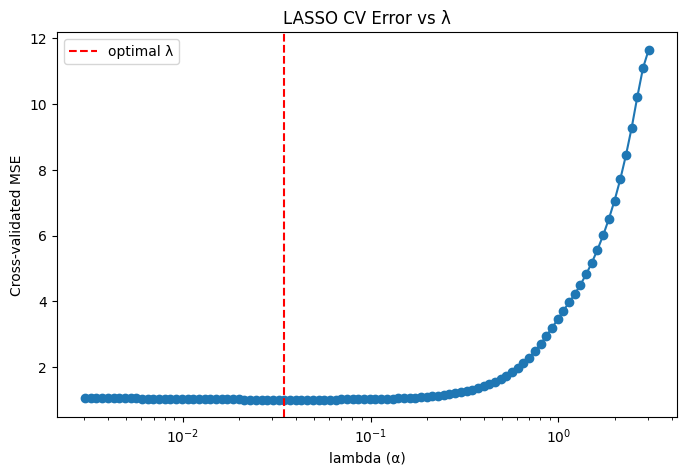

最佳 λ (alpha): 0.03475032877918766

LASSO 係數（對應 X ~ X10）：
X: 2.1514
X2: -1.0041
X3: 0.8218
X4: -0.0000
X5: 0.1253
X6: -0.0000
X7: 0.0000
X8: -0.0000
X9: 0.0000
X10: -0.0000


In [11]:

import matplotlib.pyplot as plt

# predictors matrix
X_mat = data.values    # data 包含 X ~ X10
y = Y1

# LASSO + CV 預設使用 MSE 來選 λ
lasso_cv = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=0)
)
lasso_cv.fit(X_mat, y)

# 取出真正的 LASSO 模型
lasso = lasso_cv.named_steps['lassocv']

# ====== plot CV error vs lambda ======
plt.figure(figsize=(8,5))
plt.semilogx(lasso.alphas_, lasso.mse_path_.mean(axis=1), marker='o')
plt.axvline(lasso.alpha_, color='red', linestyle='--', label='optimal λ')
plt.xlabel("lambda (α)")
plt.ylabel("Cross-validated MSE")
plt.title("LASSO CV Error vs λ")
plt.legend()
plt.show()

# ====== print coefficients ======
print("最佳 λ (alpha):", lasso.alpha_)
print("\nLASSO 係數（對應 X ~ X10）：")
for name, coef in zip(data.columns, lasso.coef_):
    print(f"{name}: {coef:.4f}")


只有 (1-3) 的迴歸係數為非零，其餘高次項（4-10）皆被 LASSO 壓縮為 0

(f) Now generate a response vector Y according to the model</br>
Y= β0 + β7X7 + ϵ,</br>
and perform forward stepwise selection and the lasso. Discuss</br>
the results obtained.</br>

【(f) Forward】最佳模型（Cp 最低）包含變數： ['X7']

【(f) Forward】迴歸係數：
const    3.061912
X7       5.002583
dtype: float64


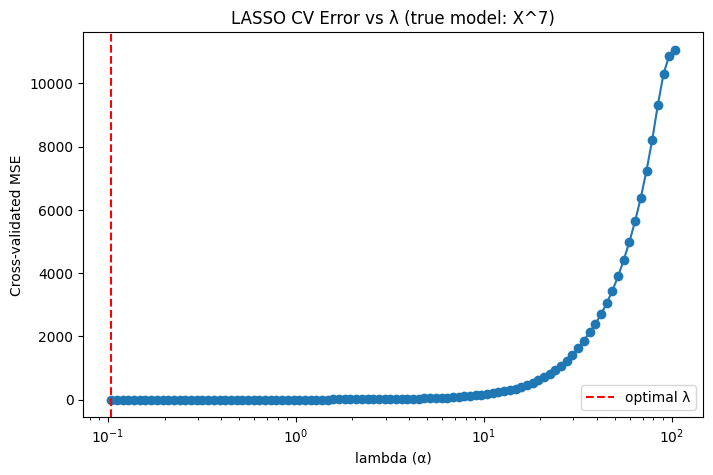

【(f) LASSO】最佳 λ (alpha): 0.10412628100000576

【(f) LASSO】係數（對應 X ~ X10）：
X: -0.4117
X2: -0.0000
X3: 0.0000
X4: -0.0000
X5: 16.0980
X6: 0.0000
X7: 69.1203
X8: 0.0000
X9: 19.4574
X10: 0.0000


In [12]:
beta0_f, beta7_f = 3.0, 5.0   # 係數你可以自己決定
Y2 = beta0_f + beta7_f * (X**7) + eps

# Forward
best_selected_fwd, best_cp_fwd, best_model_fwd, models_fwd = forward_stepwise(data, Y2)

print("【(f) Forward】最佳模型（Cp 最低）包含變數：", best_selected_fwd)
print("\n【(f) Forward】迴歸係數：")
print(best_model_fwd.params)



X_mat = data.values   # 一樣是 X ~ X10
y2 = Y2

lasso_cv_f = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=0)
)
lasso_cv_f.fit(X_mat, y2)

lasso_f = lasso_cv_f.named_steps["lassocv"]

# 畫 CV error vs lambda
plt.figure(figsize=(8,5))
plt.semilogx(lasso_f.alphas_, lasso_f.mse_path_.mean(axis=1), marker='o')
plt.axvline(lasso_f.alpha_, color='red', linestyle='--', label='optimal λ')
plt.xlabel("lambda (α)")
plt.ylabel("Cross-validated MSE")
plt.title("LASSO CV Error vs λ (true model: X^7)")
plt.legend()
plt.show()

print("【(f) LASSO】最佳 λ (alpha):", lasso_f.alpha_)
print("\n【(f) LASSO】係數（對應 X ~ X10）：")
for name, coef in zip(data.columns, lasso_f.coef_):
    print(f"{name}: {coef:.4f}")

